# Joint DANN eval — Lipschitz encoder + MAF5, v3

Evaluates `exp-v3_encoder-lipschitz_dann_flow-maf5`: 300k sims, WDGRL (λ=0.5, 100-ep ramp),
Mixup real augmentation, 400 epochs. Final: task=12.84, w1=0.85.

Key difference from OT pipeline: encoder is jointly trained with WDGRL domain adaptation — no
separate `enc_real`/`enc_joint`. A single `encoder.pt` maps both sims and reals; the flow
samples directly on `encoder(x_real)` without a nearest-neighbour proxy.

1. **Training curves** — task loss, W1, lambda
2. **Latent space** — PCA/UMAP: encoder(sim) vs encoder(real)
3. **Direct inference** — sample flow on real patients
4. **Parameter scatter** — posterior mean vs GT (Cas, Eap, Rap/PVR, Ras/SVR)
5. **Hypertension stratification**

In [15]:
import json, sys, h5py, csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

try:
    ROOT = Path(globals()['_dh'][0]).parent
    assert (ROOT / 'dataset.py').exists()
except:
    ROOT = Path('/home/sa4604/cv-dann-sbi')
sys.path.insert(0, str(ROOT))

from dataset import (
    load_stats, load_manifest, ReducedCVDataset,
    PARAM_KEYS_INFER, N_CHANNELS, T, WAVE_KEYS_CONT,
)
from models import LipschitzReducedAutoencoderEncoder

WAVE_KEYS_REAL = ['Prv', 'Pra', 'Pvp', 'Pap']

device = torch.device('cuda:0')
print('device:', device)

device: cuda:0


In [16]:
RUN        = 'exp-v3_encoder-lipschitz_dann_flow-maf5'
VERSION    = '3'
RUN_DIR    = ROOT / f'outputs/{RUN}'

REAL_DATA  = Path('/home/sa4604/real_data/onebeat_300patients')
SIM_ROOT   = Path('/media/local/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314')
STATS_PATH = ROOT / 'norm_stats.json'

N_POSTERIOR_SAMPLES = 1000
N_SIM_PCA           = 500

stats    = load_stats(STATS_PATH)
manifest = load_manifest(SIM_ROOT / 'manifest_train.json')
lo_t = torch.tensor([manifest['config']['pvar_low'][k]  for k in PARAM_KEYS_INFER], dtype=torch.float32)
hi_t = torch.tensor([manifest['config']['pvar_high'][k] for k in PARAM_KEYS_INFER], dtype=torch.float32)
print('Prior bounds loaded for', len(PARAM_KEYS_INFER), 'parameters')

Prior bounds loaded for 24 parameters


## Training curves

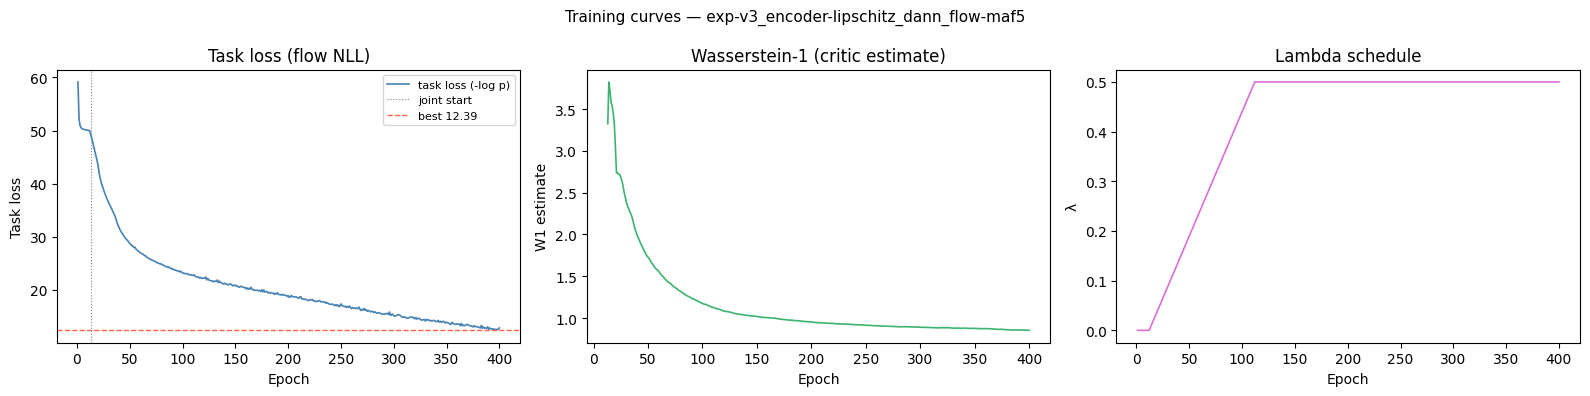

Total epochs: 400  best task (joint): 12.3933  final W1: 0.8533


In [17]:
csv_files = sorted(RUN_DIR.glob('train_log_*.csv'))
assert csv_files, f'No train_log CSV in {RUN_DIR}'

epochs, task_l, w1_l, gp_l, lam_l, phase_l = [], [], [], [], [], []
with open(csv_files[-1]) as f:
    for row in csv.DictReader(f):
        epochs.append(int(row['epoch']))
        task_l.append(float(row['task']))
        w1_l.append(float(row['w1_est']))
        gp_l.append(float(row['gp']))
        lam_l.append(float(row['lambda']))
        phase_l.append(int(row['phase']))

epochs = np.array(epochs)
joint_start = next(i for i, p in enumerate(phase_l) if p == 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(epochs, task_l, color='steelblue', linewidth=1.2, label='task loss (-log p)')
ax.axvline(epochs[joint_start], color='grey', linestyle=':', linewidth=0.8, label='joint start')
best_task = min(task_l[joint_start:])
ax.axhline(best_task, color='tomato', linestyle='--', linewidth=1, label=f'best {best_task:.2f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Task loss'); ax.set_title('Task loss (flow NLL)')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(epochs[joint_start:], w1_l[joint_start:], color='mediumseagreen', linewidth=1.2)
ax.set_xlabel('Epoch'); ax.set_ylabel('W1 estimate'); ax.set_title('Wasserstein-1 (critic estimate)')

ax = axes[2]
ax.plot(epochs, lam_l, color='orchid', linewidth=1.2)
ax.set_xlabel('Epoch'); ax.set_ylabel('λ'); ax.set_title('Lambda schedule')

fig.suptitle(f'Training curves — {RUN}', fontsize=11)
plt.tight_layout(); plt.show()
print(f'Total epochs: {len(epochs)}  best task (joint): {best_task:.4f}  final W1: {w1_l[-1]:.4f}')

## Load models

In [18]:
encoder = LipschitzReducedAutoencoderEncoder(latent_dim=128).to(device)
encoder.load_state_dict(torch.load(RUN_DIR / 'encoder.pt', map_location=device))
encoder.eval()
print('Encoder loaded:', encoder.describe())

flow_net = torch.load(RUN_DIR / 'flow_net.pt', map_location=device, weights_only=False)
flow_net.eval()
print('Flow loaded:', type(flow_net).__name__)

Encoder loaded: {'type': 'LipschitzReducedAutoencoderEncoder', 'input_waveforms': '(4, 201)', 'input_scalars': 'Pas_mean, Pas_max, Pas_min, SV, HR_z', 'latent_dim': 128, 'proj_hidden': None, 'sn_ceiling': 2.0, 'n_params': 439617}
Flow loaded: NFlowsFlow


## Load real patients

In [19]:
w = stats['waves']
p = stats['parameters']
wave_mean = torch.tensor([w[k]['mean'] for k in WAVE_KEYS_REAL], dtype=torch.float32).unsqueeze(1)
wave_std  = torch.tensor([w[k]['std']  for k in WAVE_KEYS_REAL], dtype=torch.float32).unsqueeze(1)
pas_mean, pas_std = w['Pas']['mean'], w['Pas']['std'] + 1e-8
vlv_std           = w['Vlv']['std'] + 1e-8
hr_mean,  hr_std  = p['HR']['mean'],  p['HR']['std']  + 1e-8

patients = []
for fpath in sorted(REAL_DATA.glob('*.h5')):
    beats_x, gt = [], {}
    with h5py.File(fpath, 'r') as f:
        for bk in sorted(f.keys()):
            if not bk.startswith('beat_'): continue
            g = f[bk]
            waves = np.stack([g[f'waves/{k}'][:].astype(np.float32) for k in WAVE_KEYS_REAL])
            wt    = (torch.from_numpy(waves) - wave_mean) / (wave_std + 1e-8)
            sbp   = float(g['summaries/sbp'][()])
            dbp   = float(g['summaries/dbp'][()])
            map_  = float(g['summaries/map'][()])
            sv    = float(g['summaries/sv'][()])
            hr    = float(g['parameters/HR'][()])
            sc = torch.tensor([
                (map_ - pas_mean) / pas_std,
                (sbp  - pas_mean) / pas_std,
                (dbp  - pas_mean) / pas_std,
                sv    / vlv_std,
                (hr   - hr_mean)  / hr_std,
            ], dtype=torch.float32)
            beats_x.append(torch.cat([wt.reshape(-1), sc]))
            if not gt:
                gt = {k: float(g[f'parameters/{k}'][()]) for k in f[bk]['parameters'].keys()}
                gt['sbp'] = sbp; gt['dbp'] = dbp; gt['map'] = map_; gt['sv'] = sv
    if beats_x:
        x_beats = torch.stack(beats_x)
        patients.append(dict(file=fpath.stem, x_beats=x_beats, x_avg=x_beats.mean(0), gt=gt))

print(f'Loaded {len(patients)} patients, {sum(len(p["x_beats"]) for p in patients)} total beats')

Loaded 802 patients, 802 total beats


## Latent space — PCA and UMAP

Key diagnostic: does `encoder(x_real)` fall inside the `encoder(x_sim)` cloud?
WDGRL was trained to minimize W1 between these distributions.

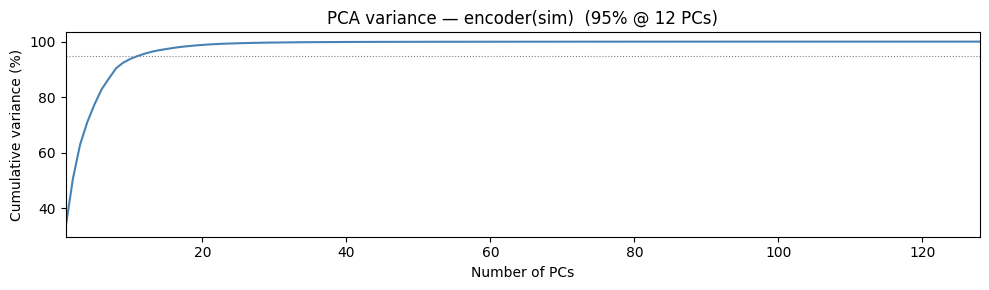

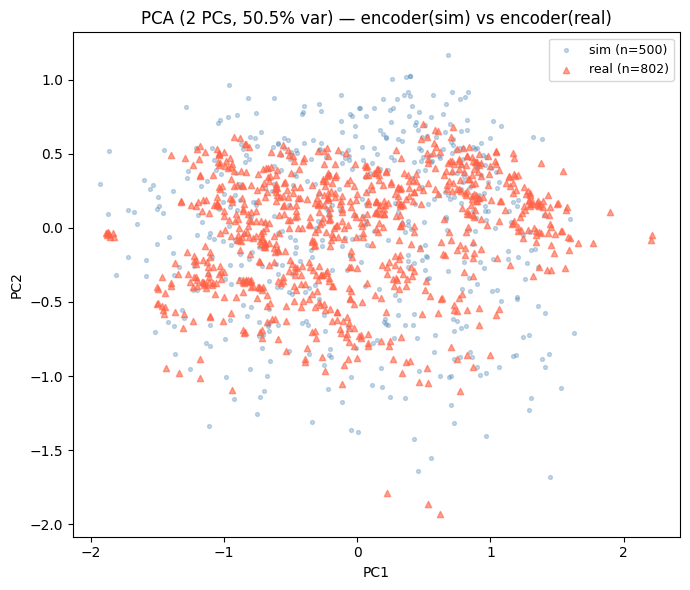

Running UMAP (12 PCs)...


/home/sa4604/cv-dann-sbi/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


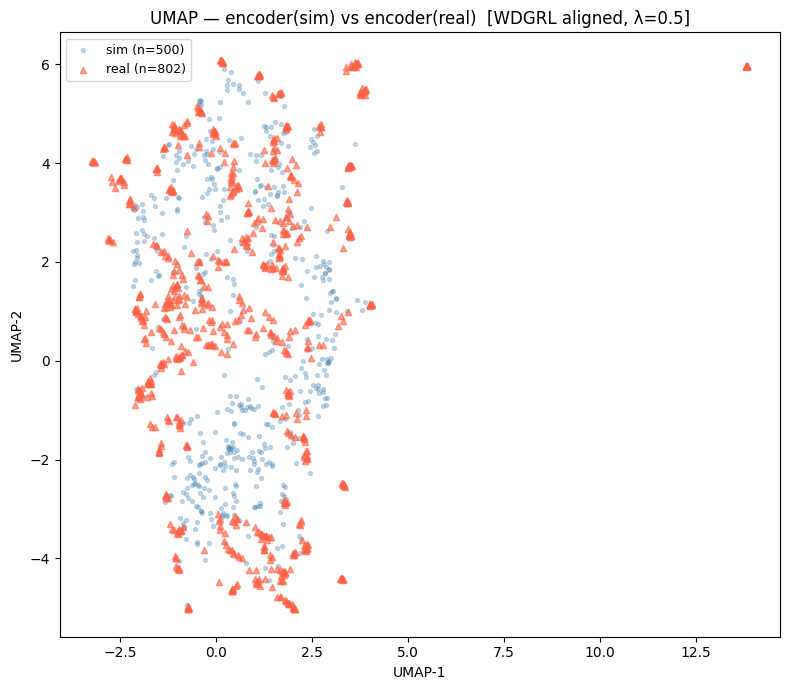

encoder(sim)  mean_std=0.116
encoder(real) mean_std=0.098  in sim bbox: 660/802 (82.3%)


In [20]:
from sklearn.decomposition import PCA
import umap

from torch.utils.data import DataLoader

ds_pca = ReducedCVDataset(str(SIM_ROOT / 'train'), manifest['index'][:N_SIM_PCA], stats)
_, x_sim_pca = next(iter(DataLoader(ds_pca, batch_size=N_SIM_PCA, num_workers=0)))
ds_pca.close()

with torch.no_grad():
    z_sim  = encoder(x_sim_pca.to(device)).cpu().numpy()
    z_real = torch.stack([
        encoder(pat['x_avg'].unsqueeze(0).to(device)).squeeze(0)
        for pat in patients
    ]).cpu().numpy()

# PCA variance
pca_full = PCA().fit(z_sim)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_95     = int((cumvar < 0.95).sum()) + 1

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(1, len(cumvar)+1), cumvar * 100, linewidth=1.5, color='steelblue')
ax.axhline(95, color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel('Number of PCs'); ax.set_ylabel('Cumulative variance (%)')
ax.set_title(f'PCA variance — encoder(sim)  (95% @ {n_95} PCs)')
ax.set_xlim(1, 128); plt.tight_layout(); plt.show()

# 2-PC scatter
pca2 = PCA(n_components=2).fit(z_sim)
zs2  = pca2.transform(z_sim)
zr2  = pca2.transform(z_real)
var  = pca2.explained_variance_ratio_.sum() * 100

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(zs2[:, 0], zs2[:, 1], s=8,  alpha=0.3, color='steelblue', label=f'sim (n={N_SIM_PCA})')
ax.scatter(zr2[:, 0], zr2[:, 1], s=20, alpha=0.6, color='tomato',    label=f'real (n={len(patients)})', marker='^', zorder=5)
ax.set_title(f'PCA (2 PCs, {var:.1f}% var) — encoder(sim) vs encoder(real)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# UMAP
print(f'Running UMAP ({n_95} PCs)...')
z_all  = pca_full.transform(np.concatenate([z_sim, z_real]))[:, :n_95]
z_umap = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.1).fit_transform(z_all)
ns     = len(z_sim)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(z_umap[:ns, 0], z_umap[:ns, 1], s=8,  alpha=0.3, color='steelblue', label=f'sim (n={ns})')
ax.scatter(z_umap[ns:, 0], z_umap[ns:, 1], s=20, alpha=0.6, color='tomato',    label=f'real (n={len(patients)})', marker='^', zorder=5)
ax.set_title(f'UMAP — encoder(sim) vs encoder(real)  [WDGRL aligned, λ=0.5]')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

in_bounds = np.all((z_real >= z_sim.min(axis=0)) & (z_real <= z_sim.max(axis=0)), axis=1)
print(f'encoder(sim)  mean_std={z_sim.std(axis=0).mean():.3f}')
print(f'encoder(real) mean_std={z_real.std(axis=0).mean():.3f}  in sim bbox: {in_bounds.sum()}/{len(z_real)} ({in_bounds.mean()*100:.1f}%)')

## UMAP colored by parameter values

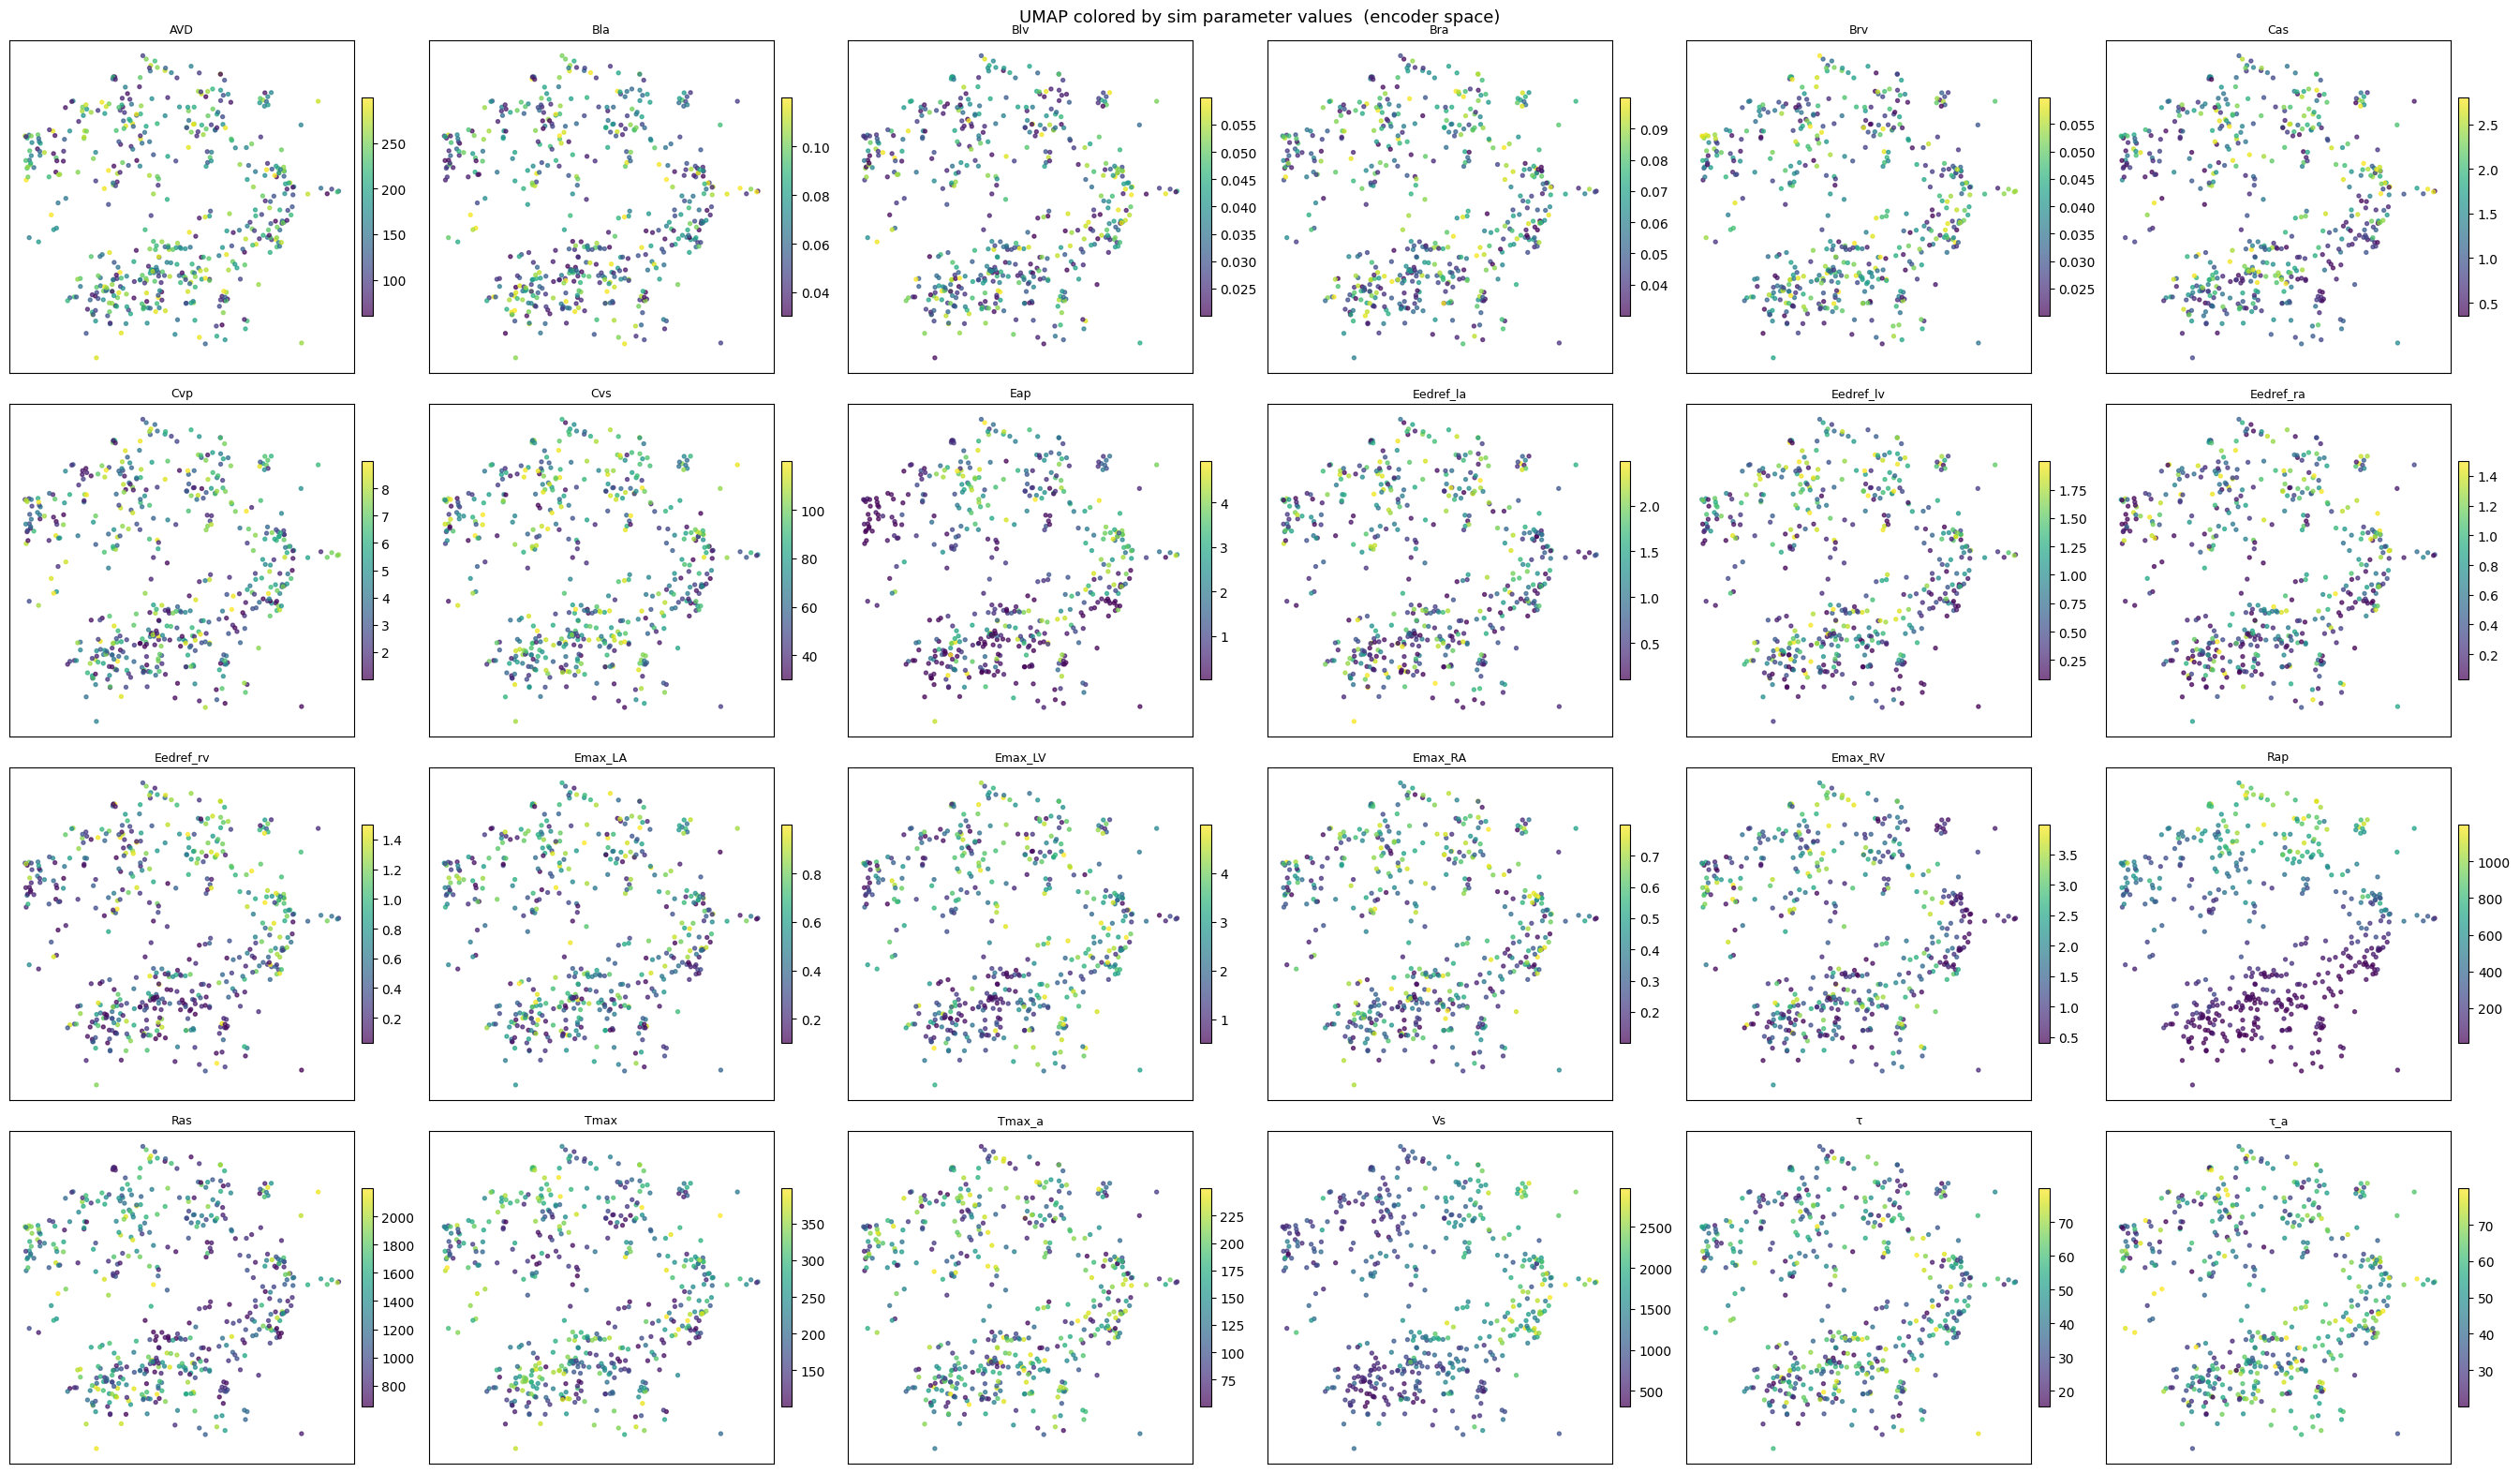

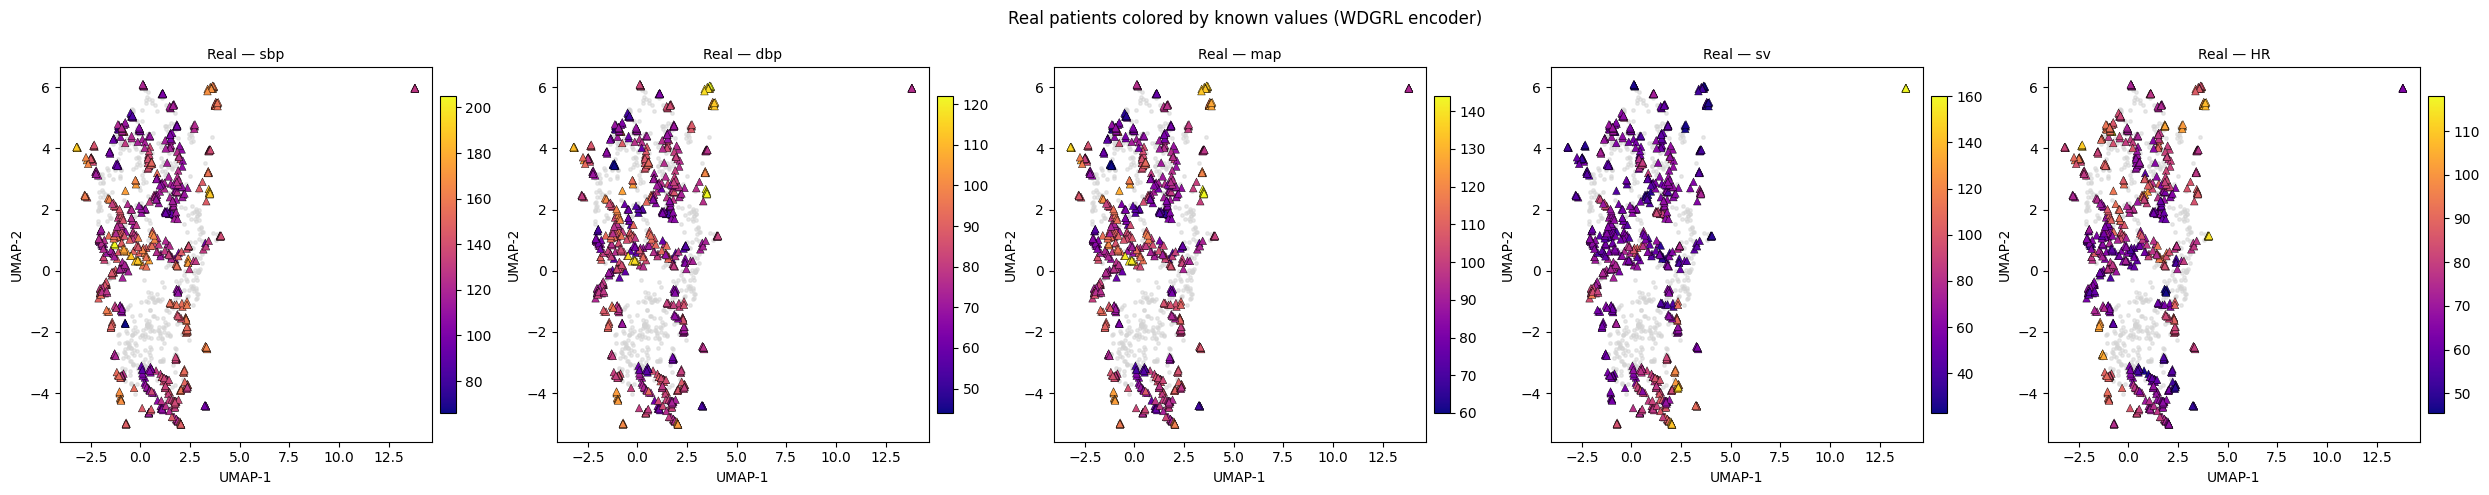

In [21]:
ds_theta = ReducedCVDataset(str(SIM_ROOT / 'train'), manifest['index'][:N_SIM_PCA], stats)
theta_sim_pca = torch.stack([ds_theta[i][0] for i in range(N_SIM_PCA)]).numpy()
ds_theta.close()

ncols, nrows = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
for i, name in enumerate(PARAM_KEYS_INFER):
    ax = axes[i // ncols, i % ncols]
    sc = ax.scatter(z_umap[:ns, 0], z_umap[:ns, 1], c=theta_sim_pca[:, i],
                    cmap='viridis', s=8, alpha=0.7, rasterized=True)
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
    ax.set_title(name, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
for i in range(len(PARAM_KEYS_INFER), nrows * ncols):
    axes[i // ncols, i % ncols].axis('off')
fig.suptitle('UMAP colored by sim parameter values  (encoder space)', fontsize=13)
plt.tight_layout(); plt.show()

hemo_keys = ['sbp', 'dbp', 'map', 'sv', 'HR']
hemo_keys = [k for k in hemo_keys if k in patients[0]['gt']]
fig, axes = plt.subplots(1, len(hemo_keys), figsize=(5 * len(hemo_keys), 5))
for ai, key in enumerate(hemo_keys):
    vals = np.array([pat['gt'].get(key, np.nan) for pat in patients])
    mask = ~np.isnan(vals)
    ax = axes[ai]
    ax.scatter(z_umap[:ns, 0], z_umap[:ns, 1], s=6, color='lightgrey', alpha=0.5, rasterized=True)
    sc = ax.scatter(z_umap[ns:][mask, 0], z_umap[ns:][mask, 1],
                    c=vals[mask], cmap='plasma', s=30, marker='^',
                    edgecolors='black', linewidths=0.3, zorder=5)
    plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
    ax.set_title(f'Real — {key}', fontsize=10)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
fig.suptitle('Real patients colored by known values (WDGRL encoder)', fontsize=12)
plt.tight_layout(); plt.show()

## Direct inference — flow on real patients

No nearest-neighbour proxy needed: `encoder(x_real)` is directly in sim latent space
(that's what WDGRL trained for). Sample `flow(z_real)` directly.

In [22]:
cas_idx = PARAM_KEYS_INFER.index('Cas')
eap_idx = PARAM_KEYS_INFER.index('Eap')
rap_idx = PARAM_KEYS_INFER.index('Rap')
ras_idx = PARAM_KEYS_INFER.index('Ras')

import time
print(f'Direct inference on {len(patients)} real patients (N={N_POSTERIOR_SAMPLES} samples each)...')

cas_d, eap_d, rap_d, ras_d, accept_rates, theta_means = [], [], [], [], [], []
t0 = time.time()

for pi, pat in enumerate(patients):
    x = pat['x_avg'].unsqueeze(0).to(device)
    with torch.no_grad():
        z       = encoder(x)                                              # (1, latent_dim)
        samples = flow_net.sample((N_POSTERIOR_SAMPLES,), condition=z)   # (N, 1, 24)
        samples = samples.squeeze(1).cpu()                                # (N, 24)
    in_prior = ((samples >= lo_t) & (samples <= hi_t)).all(dim=1)
    accept   = in_prior.float().mean().item()
    accept_rates.append(accept)
    s_ok  = samples[in_prior] if in_prior.any() else samples
    means = s_ok.mean(0).numpy()
    theta_means.append(means)
    cas_d.append(means[cas_idx]); eap_d.append(means[eap_idx])
    rap_d.append(means[rap_idx]); ras_d.append(means[ras_idx])
    if pi % 100 == 0 or pi < 3:
        print(f'  [{pi:3d}] accept={accept:.3f}  '
              f'Cas={cas_d[-1]:.3f} (GT={pat["gt"].get("Cas", float("nan")):.3f})  '
              f'({time.time()-t0:.0f}s)')

cas_d = np.array(cas_d); eap_d = np.array(eap_d)
rap_d = np.array(rap_d); ras_d = np.array(ras_d)
accept_rates = np.array(accept_rates)
theta_means  = np.stack(theta_means)
print(f'\nMean acceptance: {accept_rates.mean():.3f}  '
      f'({(accept_rates > 0).sum()}/{len(patients)} patients with nonzero acceptance)')

Direct inference on 802 real patients (N=1000 samples each)...
  [  0] accept=0.046  Cas=0.947 (GT=1.230)  (0s)
  [  1] accept=0.019  Cas=0.888 (GT=1.190)  (0s)
  [  2] accept=0.005  Cas=0.904 (GT=1.190)  (0s)
  [100] accept=0.297  Cas=1.234 (GT=1.730)  (4s)
  [200] accept=0.000  Cas=0.635 (GT=0.910)  (7s)
  [300] accept=0.159  Cas=0.648 (GT=0.847)  (11s)
  [400] accept=0.000  Cas=0.370 (GT=0.540)  (15s)
  [500] accept=0.208  Cas=0.693 (GT=0.987)  (18s)
  [600] accept=0.222  Cas=0.893 (GT=1.320)  (22s)
  [700] accept=0.000  Cas=1.069 (GT=1.310)  (26s)
  [800] accept=0.011  Cas=0.615 (GT=0.854)  (30s)

Mean acceptance: 0.050  (321/802 patients with nonzero acceptance)


## Parameter scatter — posterior mean vs GT

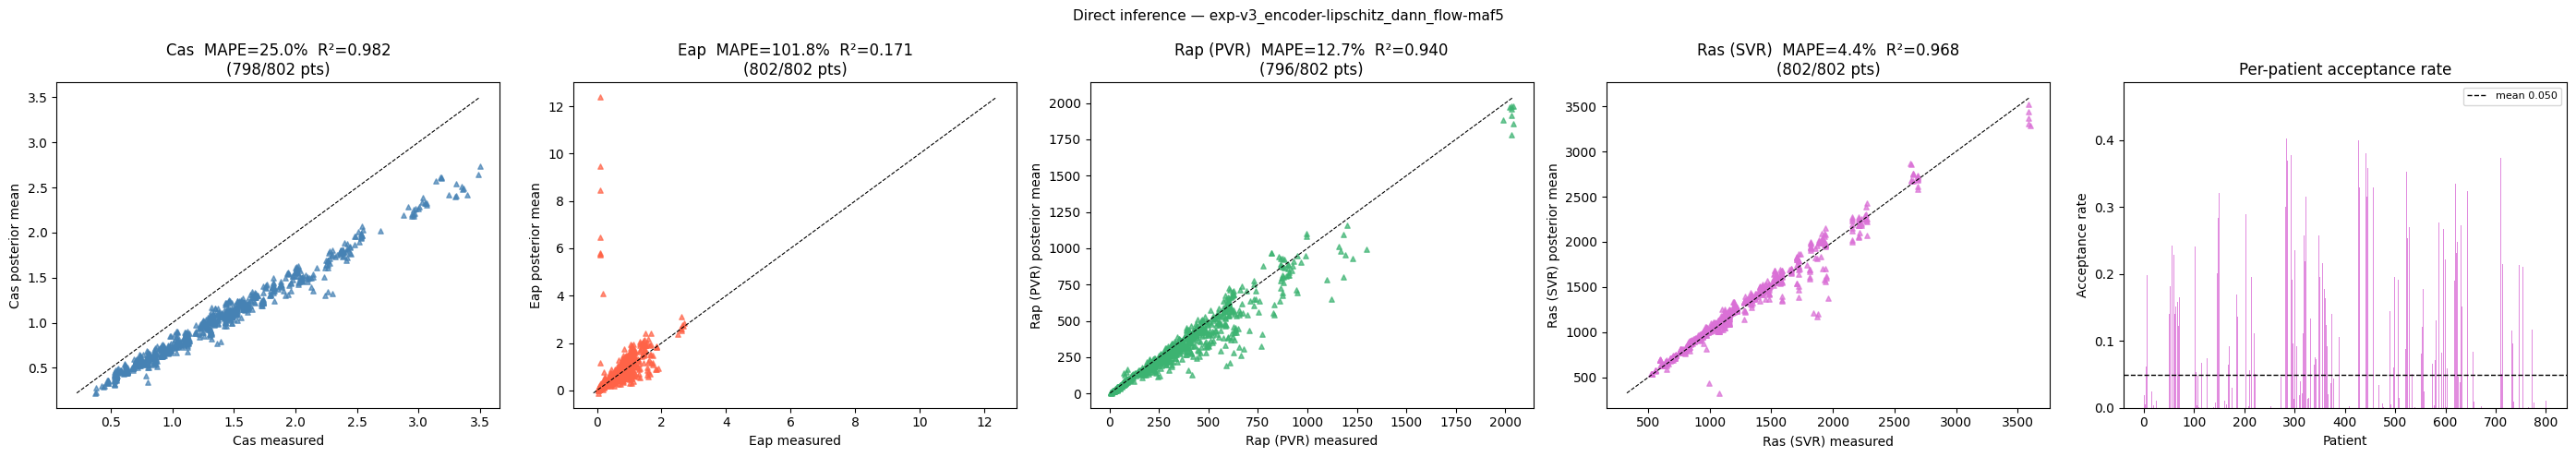


Parameter        MAPE      R²
------------------------------
Cas             25.0%   0.982
Eap            101.8%   0.171
Rap(PVR)        12.7%   0.940
Ras(SVR)         4.4%   0.968


In [23]:
from scipy.stats import pearsonr

cas_gt = np.array([pat['gt'].get('Cas', np.nan) for pat in patients])
eap_gt = np.array([pat['gt'].get('Eap', np.nan) for pat in patients])
rap_gt = np.array([pat['gt'].get('PVR', np.nan) for pat in patients])
ras_gt = np.array([pat['gt'].get('SVR', np.nan) for pat in patients])

fig, axes = plt.subplots(1, 5, figsize=(28, 5))
for ax, pred, gt, name, color in [
    (axes[0], cas_d, cas_gt, 'Cas',       'steelblue'),
    (axes[1], eap_d, eap_gt, 'Eap',       'tomato'),
    (axes[2], rap_d, rap_gt, 'Rap (PVR)', 'mediumseagreen'),
    (axes[3], ras_d, ras_gt, 'Ras (SVR)', 'orchid'),
]:
    valid = ~np.isnan(pred) & ~np.isnan(gt) & (gt >= 0)
    if valid.any():
        lo = np.nanmin([gt[valid].min(), pred[valid].min()])
        hi = np.nanmax([gt[valid].max(), pred[valid].max()])
        ax.scatter(gt[valid], pred[valid], s=15, alpha=0.7, color=color, marker='^')
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
        mape = np.nanmean(np.abs(pred[valid] - gt[valid]) / (np.abs(gt[valid]) + 1e-9)) * 100
        r2   = pearsonr(gt[valid], pred[valid])[0] ** 2
        ax.set_title(f'{name}  MAPE={mape:.1f}%  R²={r2:.3f}\n({valid.sum()}/{len(patients)} pts)')
    else:
        ax.set_title(f'{name}  0 valid')
    ax.set_xlabel(f'{name} measured'); ax.set_ylabel(f'{name} posterior mean')

ax = axes[4]
ax.bar(range(len(patients)), accept_rates, color='orchid', alpha=0.8)
ax.axhline(accept_rates.mean(), color='black', linestyle='--', linewidth=1,
           label=f'mean {accept_rates.mean():.3f}')
ax.set_xlabel('Patient'); ax.set_ylabel('Acceptance rate')
ax.set_title('Per-patient acceptance rate'); ax.legend(fontsize=8)

fig.suptitle(f'Direct inference — {RUN}', fontsize=11)
plt.tight_layout(); plt.show()

print(f'\n{"Parameter":<12} {"MAPE":>8} {"R²":>7}')
print('-' * 30)
for pred, gt, name in [
    (cas_d, cas_gt, 'Cas'), (eap_d, eap_gt, 'Eap'),
    (rap_d, rap_gt, 'Rap(PVR)'), (ras_d, ras_gt, 'Ras(SVR)'),
]:
    valid = ~np.isnan(pred) & ~np.isnan(gt) & (gt >= 0)
    if valid.sum() > 1:
        mape = np.nanmean(np.abs(pred[valid] - gt[valid]) / (np.abs(gt[valid]) + 1e-9)) * 100
        r2   = pearsonr(gt[valid], pred[valid])[0] ** 2
        print(f'{name:<12} {mape:>7.1f}%  {r2:>6.3f}')

## Parameter correlation heatmap

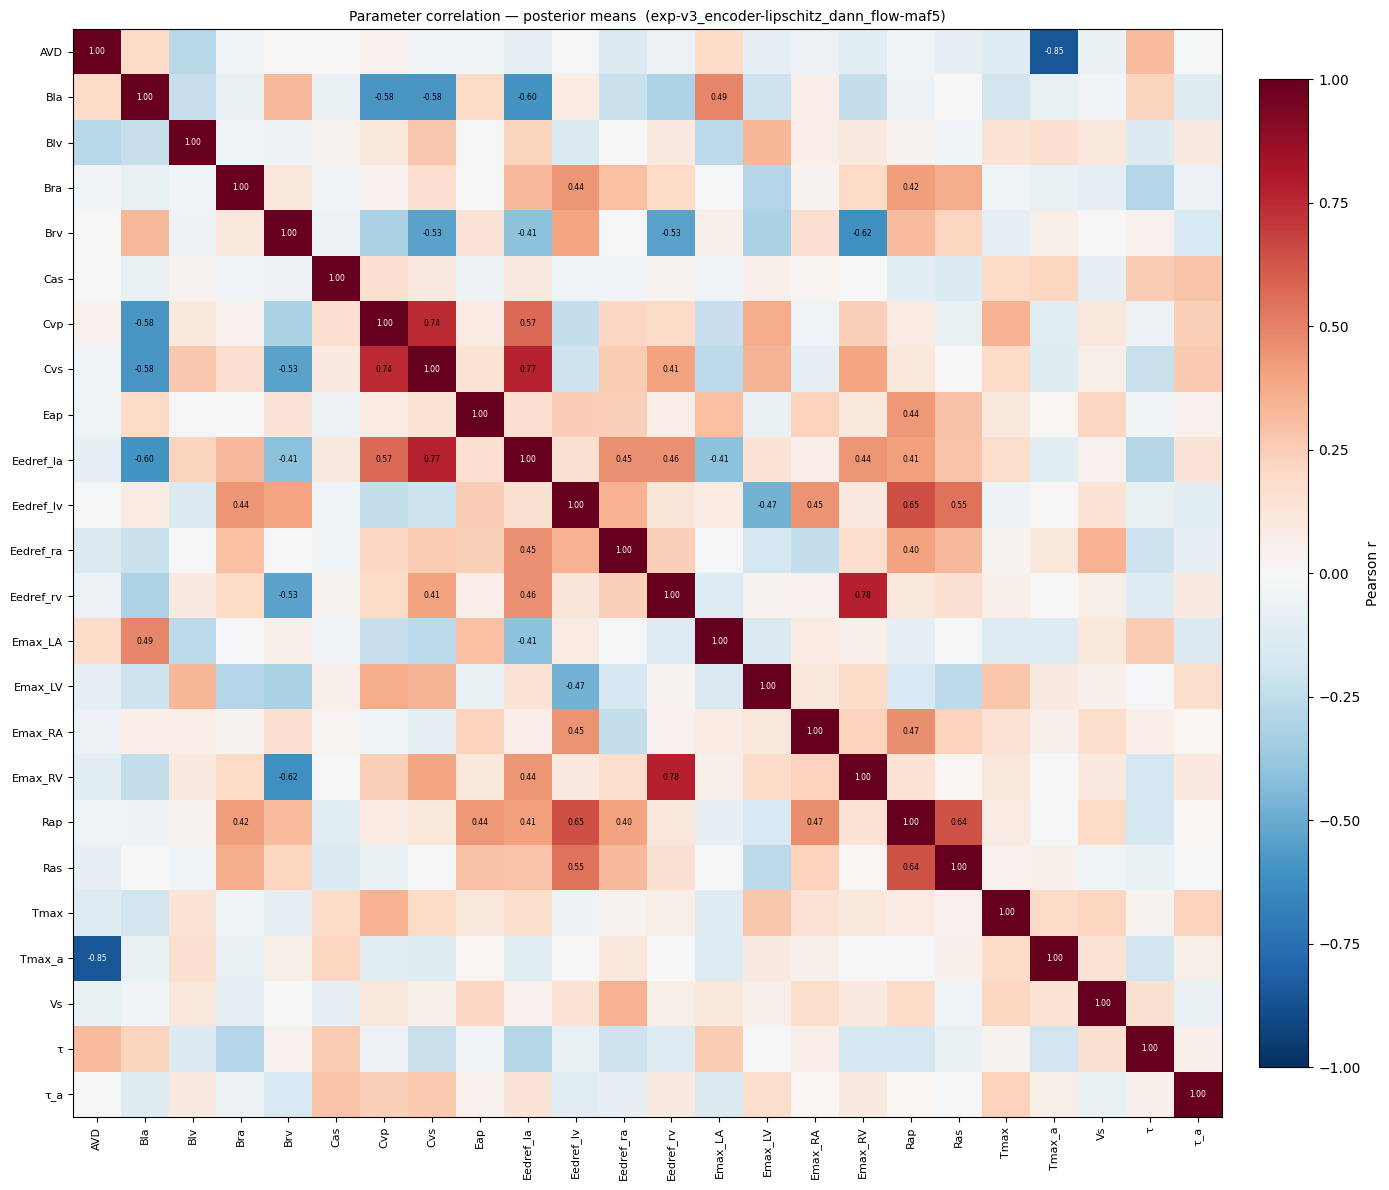

In [24]:
corr = np.corrcoef(theta_means.T)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label='Pearson r')
ticks = range(len(PARAM_KEYS_INFER))
ax.set_xticks(ticks); ax.set_xticklabels(PARAM_KEYS_INFER, rotation=90, fontsize=8)
ax.set_yticks(ticks); ax.set_yticklabels(PARAM_KEYS_INFER, fontsize=8)
for i in range(len(PARAM_KEYS_INFER)):
    for j in range(len(PARAM_KEYS_INFER)):
        val = corr[i, j]
        if abs(val) > 0.4:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=5.5, color='black' if abs(val) < 0.8 else 'white')
ax.set_title(f'Parameter correlation — posterior means  ({RUN})', fontsize=10)
plt.tight_layout(); plt.show()

## Sim evaluation — posterior scatter, error metrics, and credible interval coverage

Uses held-out test sims (true theta known). For each sim: `encoder(x) → z → flow.sample(1000)`.
Posterior mean vs true theta gives MAPE/MAE/R²; posterior quantiles give coverage calibration.

In [ ]:
N_SIM_EVAL = 1000
ncols, nrows = 6, 4

manifest_test = load_manifest(SIM_ROOT / 'manifest_test.json')
ds_test = ReducedCVDataset(str(SIM_ROOT / 'test'), manifest_test['index'][:N_SIM_EVAL], stats)
theta_test, x_test = zip(*[ds_test[i] for i in range(len(ds_test))])
ds_test.close()
theta_test = torch.stack(list(theta_test))  # (N, 24) — true parameters
x_test     = torch.stack(list(x_test))      # (N, obs_dim)
print(f'Test sims: {tuple(theta_test.shape)}  obs: {tuple(x_test.shape)}')

# Run posterior inference on each test sim
print(f'Running inference on {N_SIM_EVAL} test sims...')
sim_samples = []
t0 = time.time()
with torch.no_grad():
    for i in range(0, len(x_test), 64):
        x_b = x_test[i:i+64].to(device)
        z_b = encoder(x_b)
        for j in range(len(x_b)):
            s = flow_net.sample(
                (N_POSTERIOR_SAMPLES,), condition=z_b[j:j+1]
            ).squeeze(1).cpu()                    # (N, 24)
            sim_samples.append(s)
        if (i // 64) % 5 == 0:
            print(f'  {i+len(x_b)}/{N_SIM_EVAL}  ({time.time()-t0:.0f}s)', end='\r', flush=True)

sim_samples = torch.stack(sim_samples)            # (N_sims, N_posterior, 24)
sim_means   = sim_samples.mean(dim=1).numpy()     # (N_sims, 24)
theta_np    = theta_test.numpy()                  # (N_sims, 24)
print(f'\nDone. sim_samples: {tuple(sim_samples.shape)}')

In [ ]:
# Scatter plots — posterior mean vs true theta for all 24 params
ncols, nrows = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for i, name in enumerate(PARAM_KEYS_INFER):
    ax   = axes[i // ncols, i % ncols]
    pred = sim_means[:, i]
    true = theta_np[:, i]
    lo   = min(true.min(), pred.min())
    hi   = max(true.max(), pred.max())
    ax.scatter(true, pred, s=5, alpha=0.4, color='steelblue', rasterized=True)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
    mape = np.mean(np.abs(pred - true) / (np.abs(true) + 1e-9)) * 100
    mae  = np.mean(np.abs(pred - true))
    r2   = pearsonr(true, pred)[0] ** 2
    ax.set_title(f'{name}\nMAPE={mape:.1f}%  MAE={mae:.3f}  R²={r2:.3f}', fontsize=7)
    ax.set_xlabel('True', fontsize=7); ax.set_ylabel('Post. mean', fontsize=7)
    ax.tick_params(labelsize=6)

for i in range(len(PARAM_KEYS_INFER), nrows * ncols):
    axes[i // ncols, i % ncols].axis('off')

fig.suptitle(f'Posterior mean vs true theta — {N_SIM_EVAL} test sims  ({RUN})', fontsize=12)
plt.tight_layout(); plt.show()

# Error metrics table
print(f'\n{"Param":<10} {"MAPE":>8} {"MAE":>10} {"R²":>7}')
print('-' * 38)
for i, name in enumerate(PARAM_KEYS_INFER):
    pred = sim_means[:, i]; true = theta_np[:, i]
    mape = np.mean(np.abs(pred - true) / (np.abs(true) + 1e-9)) * 100
    mae  = np.mean(np.abs(pred - true))
    r2   = pearsonr(true, pred)[0] ** 2
    print(f'{name:<10} {mape:>7.1f}%  {mae:>9.4f}  {r2:>6.3f}')

In [ ]:
# Credible interval coverage calibration
# For each nominal level alpha, check what fraction of sims have true theta inside the alpha-CI.
# Perfect calibration = empirical coverage matches nominal (points on diagonal).

alphas    = np.linspace(0.05, 0.95, 19)
sim_s_np  = sim_samples.numpy()   # (N_sims, N_posterior, 24)
coverage  = np.zeros((len(alphas), len(PARAM_KEYS_INFER)))  # (n_levels, 24)

for ai, alpha in enumerate(alphas):
    lo_q = (1 - alpha) / 2 * 100
    hi_q = 100 - lo_q
    ci_lo = np.percentile(sim_s_np, lo_q, axis=1)  # (N_sims, 24)
    ci_hi = np.percentile(sim_s_np, hi_q, axis=1)
    inside = (theta_np >= ci_lo) & (theta_np <= ci_hi)  # (N_sims, 24)
    coverage[ai] = inside.mean(axis=0)

# Per-parameter calibration curves (4×6 grid)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
for i, name in enumerate(PARAM_KEYS_INFER):
    ax = axes[i // ncols, i % ncols]
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='ideal')
    ax.plot(alphas, coverage[:, i], color='tomato', linewidth=1.5, marker='o', markersize=3, label='empirical')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel('Nominal', fontsize=7); ax.set_ylabel('Empirical', fontsize=7)
    ax.tick_params(labelsize=6)
    if i == 0: ax.legend(fontsize=6)
for i in range(len(PARAM_KEYS_INFER), nrows * ncols):
    axes[i // ncols, i % ncols].axis('off')
fig.suptitle(f'Credible interval calibration — {N_SIM_EVAL} test sims  ({RUN})', fontsize=12)
plt.tight_layout(); plt.show()

# Summary: mean coverage at 90% CI across all params
cov_90 = coverage[alphas.searchsorted(0.9), :]
print(f'Coverage at 90% CI (ideal=0.90):')
print(f'  mean={cov_90.mean():.3f}  min={cov_90.min():.3f} ({PARAM_KEYS_INFER[cov_90.argmin()]})  '
      f'max={cov_90.max():.3f} ({PARAM_KEYS_INFER[cov_90.argmax()]})')
print(f'\n{"Param":<10} {"90% CI coverage":>17}')
print('-' * 30)
for i, name in enumerate(PARAM_KEYS_INFER):
    flag = '  ← overconfident' if cov_90[i] < 0.80 else ('  ← underconfident' if cov_90[i] > 0.97 else '')
    print(f'{name:<10} {cov_90[i]:>16.3f}{flag}')